# 📊 DỰ ÁN KHAI PHÁ DỮ LIỆU: DỰ ĐOÁN THU NHẬP CÓ VƯỢT 50K/NĂM

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

## TẢI VÀ KHÁM PHÁ DỮ LIỆU

In [3]:
df = pd.read_csv('adult.csv')
print(df.head())

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country incom

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [5]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [6]:
data = df.dropna()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [7]:
print('workclass',data.workclass.unique())
print('education',data.education.unique())
print('marital-status',data['marital-status'].unique())
print('occupation',data.occupation.unique())
print('relationship',data.relationship.unique())
print('race',data.race.unique())
print('gender',data.gender.unique())
print('native-country',data['native-country'].unique())

workclass <StringArray>
[         'Private',        'Local-gov',                '?',
 'Self-emp-not-inc',      'Federal-gov',        'State-gov',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str
education <StringArray>
[        '11th',      'HS-grad',   'Assoc-acdm', 'Some-college',
         '10th',  'Prof-school',      '7th-8th',    'Bachelors',
      'Masters',    'Doctorate',      '5th-6th',    'Assoc-voc',
          '9th',         '12th',      '1st-4th',    'Preschool']
Length: 16, dtype: str
marital-status <StringArray>
[        'Never-married',    'Married-civ-spouse',               'Widowed',
              'Divorced',             'Separated', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str
occupation <StringArray>
['Machine-op-inspct',   'Farming-fishing',   'Protective-serv',
                 '?',     'Other-service',    'Prof-specialty',
      'Craft-repair',      'Adm-clerical',   'Exec-managerial',
      'Tech-suppor

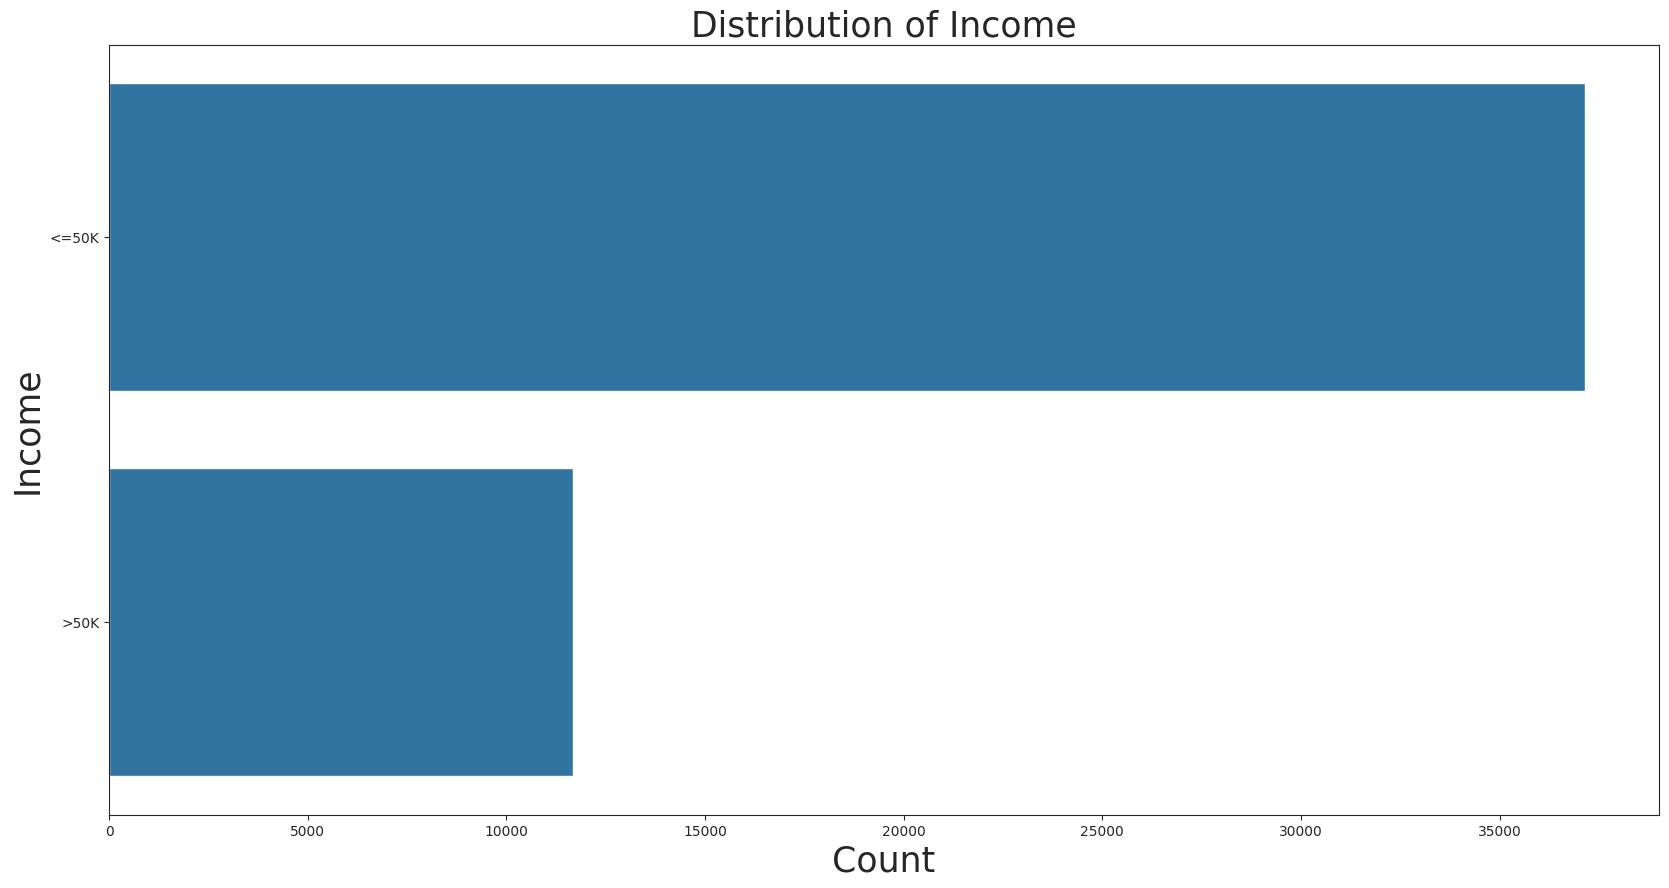

In [8]:
fig = plt.figure(figsize=(20,10))
sns.set_style("ticks")
sns.countplot(y="income", data=data)
plt.xlabel('Count',fontsize=25)
plt.ylabel('Income',fontsize=25)
plt.title('Distribution of Income',fontsize=25)
plt.show()

In [9]:
# Giáo dục được phân loại thành 4 nhóm: dropout, HighGrad, CommunityCollege, Bachelors, Masters, Doctorate
data['education'] = data['education'].replace('Preschool', 'dropout')
data['education'] = data['education'].replace('10th', 'dropout')
data['education'] = data['education'].replace('11th', 'dropout')
data['education'] = data['education'].replace('12th', 'dropout')
data['education'] = data['education'].replace('1st-4th', 'dropout')
data['education'] = data['education'].replace('5th-6th', 'dropout')
data['education'] = data['education'].replace('7th-8th', 'dropout')
data['education'] = data['education'].replace('9th', 'dropout')
data['education'] = data['education'].replace('HS-Grad', 'HighGrad')
data['education'] = data['education'].replace('HS-grad', 'HighGrad')
data['education'] = data['education'].replace('Some-college', 'CommunityCollege')
data['education'] = data['education'].replace('Assoc-acdm', 'CommunityCollege')
data['education'] = data['education'].replace('Assoc-voc', 'CommunityCollege')
data['education'] = data['education'].replace('Bachelors', 'Bachelors')
data['education'] = data['education'].replace('Masters', 'Masters')
data['education'] = data['education'].replace('Prof-school', 'Masters')
data['education'] = data['education'].replace('Doctorate', 'Doctorate')
data['education'].unique()

<StringArray>
['dropout', 'HighGrad', 'CommunityCollege', 'Masters', 'Bachelors',
 'Doctorate']
Length: 6, dtype: str

In [10]:
data[['education', 'educational-num']].groupby(['education'], as_index=False).mean().sort_values(by='educational-num', ascending=False)

,education,educational-num
2,Doctorate,16.000000
4,Masters,14.238900
0,Bachelors,13.000000
1,CommunityCollege,10.361967
3,HighGrad,9.000000
5,dropout,5.614544


In [11]:
data['marital-status'] = data['marital-status'].replace('Never-married', 'NotMarried')
data['marital-status'] = data['marital-status'].replace('Married-AF-spouse', 'Married')
data['marital-status'] = data['marital-status'].replace('Married-civ-spouse', 'Married')
data['marital-status'] = data['marital-status'].replace('Married-spouse-absent', 'NotMarried')
data['marital-status'] = data['marital-status'].replace('Separated', 'Separated')
data['marital-status'] = data['marital-status'].replace('Divorced', 'Separated')
data['marital-status'] = data['marital-status'].replace('Widowed', 'Widowed')
data['marital-status'].unique()

<StringArray>
['NotMarried', 'Married', 'Widowed', 'Separated']
Length: 4, dtype: str

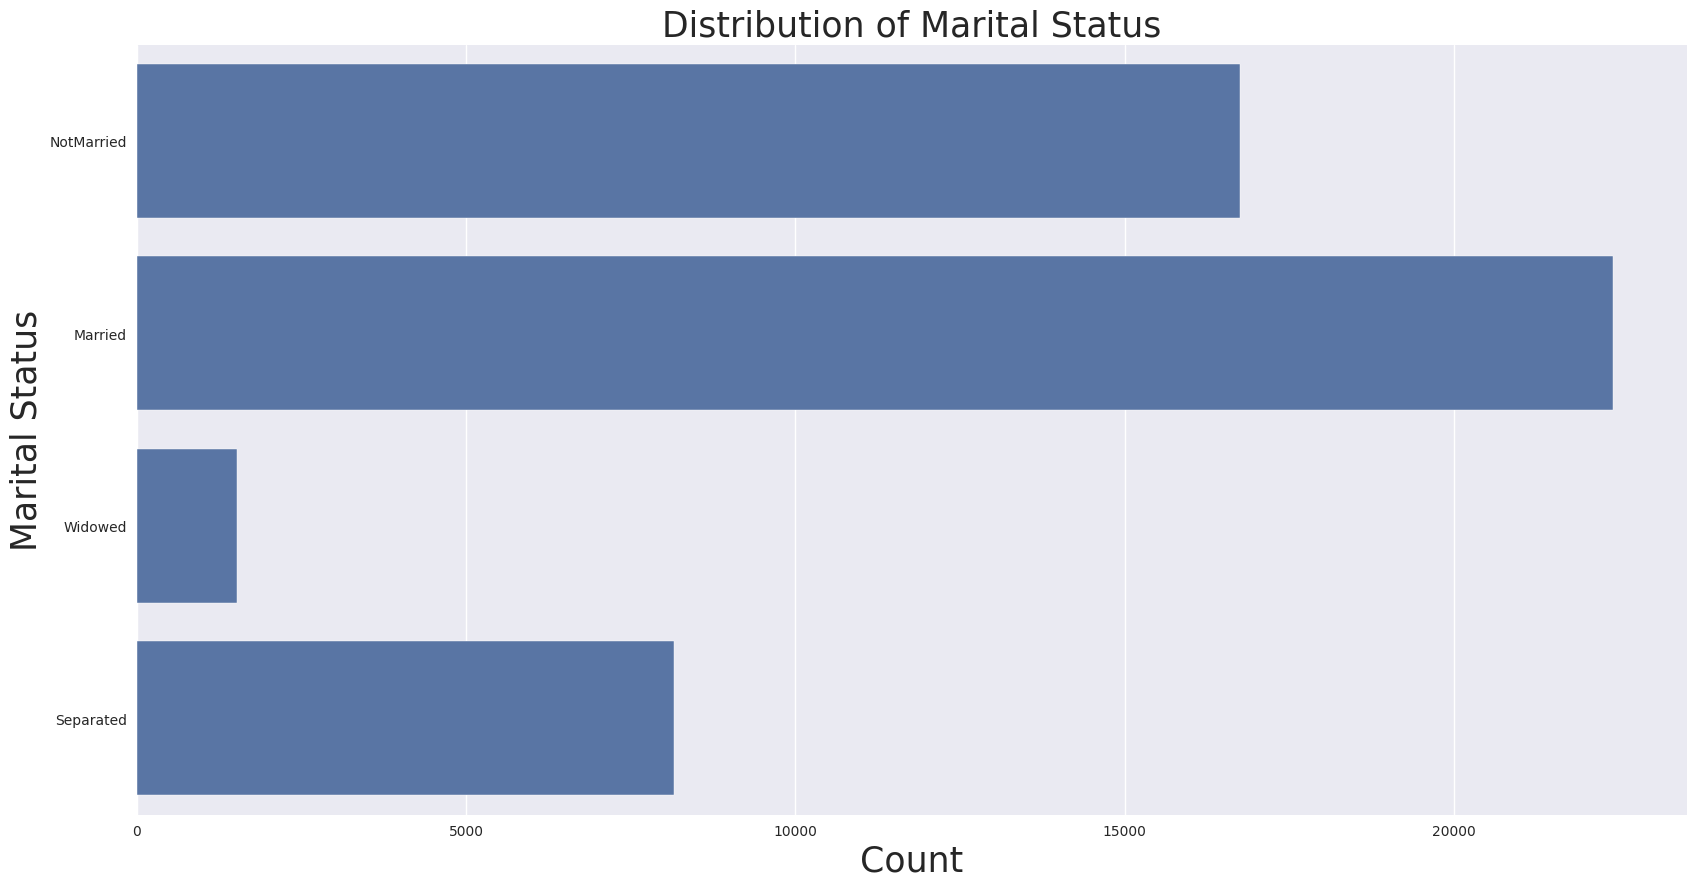

In [12]:
fig = plt.figure(figsize=(20,10))
plt.style.use("seaborn-v0_8")
sns.countplot(y="marital-status", data=data)
plt.xlabel('Count',fontsize=25)
plt.ylabel('Marital Status',fontsize=25)
plt.title('Distribution of Marital Status',fontsize=25)
plt.show()

In [13]:
drop_elements = ['education', 'native-country', 'income', 'age', 'hours-per-week']
y = data["income"]
X = data.drop(drop_elements, axis=1)
# Encode remaining categorical columns to numeric
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender']
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])
X.head()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

<Axes: >

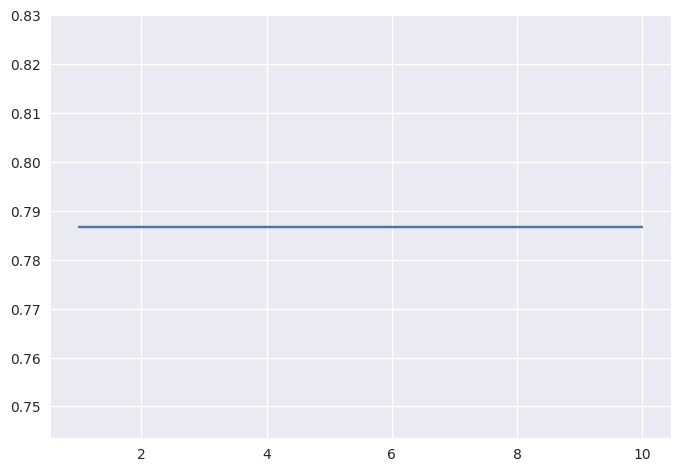

In [14]:
from sklearn.linear_model import Perceptron
accuracy_scores = []
for i in range(1, 11):
    p = Perceptron(eta0=i, random_state=1)
    p.fit(X_train, y_train)
    y_pred = p.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

sns.lineplot(x=range(1, 11), y=accuracy_scores)
    # print(f'Learning rate: {i}, Accuracy: {acc}')
# ppn = Perceptron(eta0=1, random_state=1)
# ppn.fit(X_train, y_train)

In [ ]:
# y_pred = ppn.predict(X_test)
# acc = accuracy_score(y_test, y_pred)
from sklearn.model_selection import cross_val_score
# score_ppn=cross_val_score(ppn, X,y, cv=5)
# score_ppn.mean()

NameError: name 'ppn' is not defined

#### Gaussian Naive Bayes

In [ ]:
# Gaussian Naive Bayes
gaussian = GaussianNB()
gaussian.fit(X_train, y_train)
# y_pred = gaussian.predict(X_test)
score_gaussian = gaussian.score(X_test,y_test)
print('The accuracy of Gaussian Naive Bayes is', score_gaussian)

The accuracy of Gaussian Naive Bayes is 0.794451837444979


#### Logistic Regression

In [17]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred)
print('The accuracy of Logistic Regression is', acc_logreg)

The accuracy of Logistic Regression is 0.7979322346197154


/run/media/noname/DATA/python/datamining/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
